In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 1 = benign, 0 = malignant


df = pd.concat([X, y], axis=1)

# 1. For each feature, compute the correlation with the target
correlations = df.corr()['target'].drop('target').sort_values()
print("Features most negatively correlated with benign outcome (i.e., higher value → more malignant):")
print(correlations.head(10))
print("\nFeatures most positively correlated (higher value → more benign):")
print(correlations.tail(10))

Features most negatively correlated with benign outcome (i.e., higher value → more malignant):
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64

Features most positively correlated (higher value → more benign):
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
Name: target, dtype: float64



mean radius — benign rate by decile:
bin
(6.9799999999999995, 10.26]    1.000000
(10.26, 11.366]                0.964286
(11.366, 12.012]               0.929825
(12.012, 12.726]               0.929825
(12.726, 13.37]                0.877193
(13.37, 14.058]                0.732143
(14.058, 15.056]               0.649123
(15.056, 17.068]               0.175439
(17.068, 19.53]                0.017241
(19.53, 28.11]                 0.000000
Name: target, dtype: float64

mean concave points — benign rate by decile:
bin
(-0.001, 0.0112]    1.000000
(0.0112, 0.0179]    1.000000
(0.0179, 0.0228]    0.982456
(0.0228, 0.028]     0.947368
(0.028, 0.0335]     0.877193
(0.0335, 0.0483]    0.875000
(0.0483, 0.0645]    0.403509
(0.0645, 0.0843]    0.175439
(0.0843, 0.1]       0.017544
(0.1, 0.201]        0.000000
Name: target, dtype: float64

worst area — benign rate by decile:
bin
(185.19899999999998, 384.72]    1.000000
(384.72, 475.98]                1.000000
(475.98, 544.14]                0.964

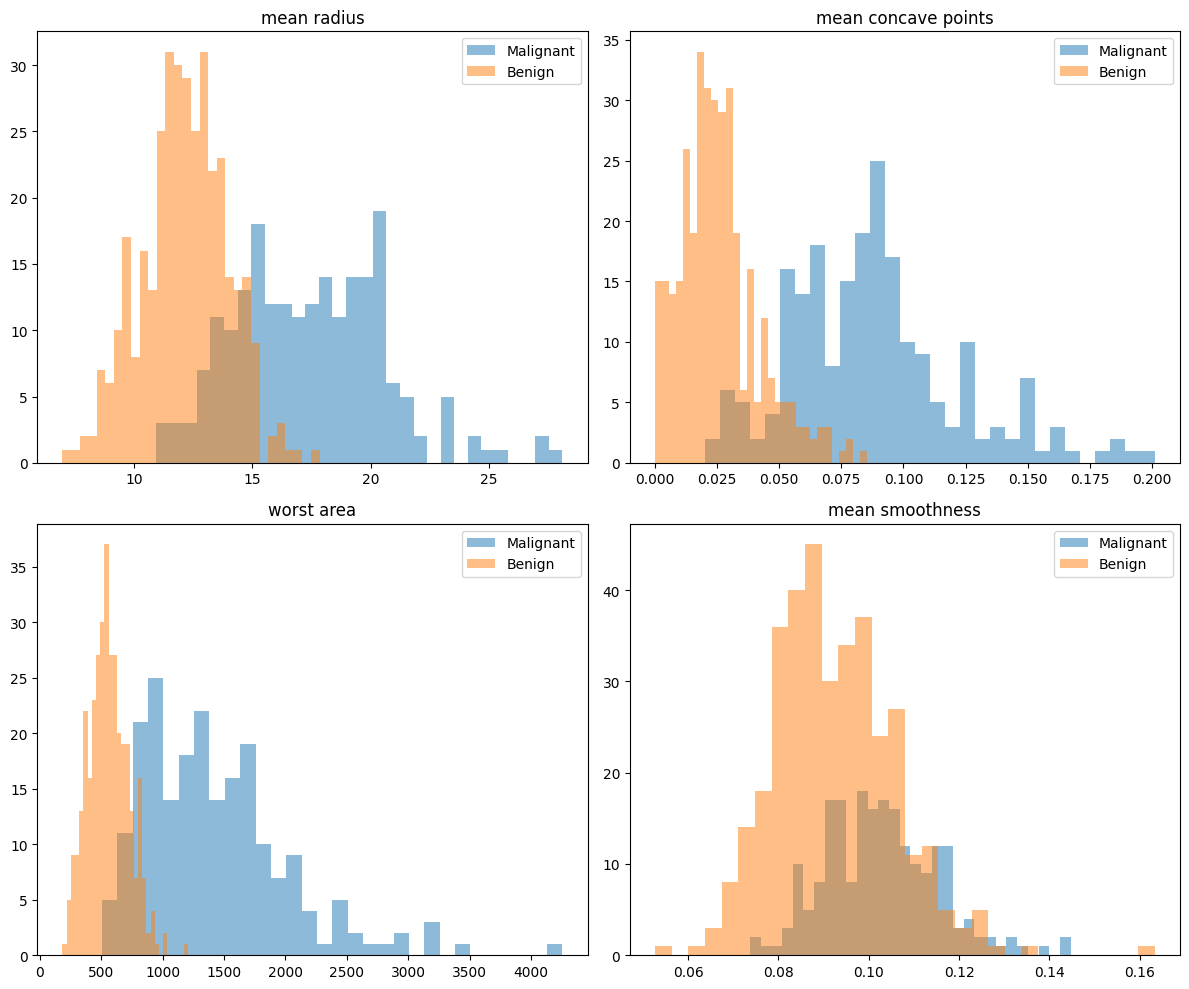

In [ ]:
# 2. Pick 3-4 features where you'd expect a monotonic relationship
candidates = ['mean radius', 'mean concave points', 'worst area', 'mean smoothness']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat in zip(axes.ravel(), candidates):
    for label, name in [(0, 'Malignant'), (1, 'Benign')]:
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=name)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.savefig('monotonic_candidates.png', dpi=150)

# 3. Check whether monotonicity actually holds
for feat in candidates:
    df['bin'] = pd.qcut(df[feat], q=10, duplicates='drop')
    rates = df.groupby('bin')['target'].mean()  # higher = more benign
    print(f"\n{feat} — benign rate by decile:")
    print(rates)
    df.drop('bin', axis=1, inplace=True)

